In [ ]:
### Libraries
import os
import cv2
import numpy as np
import pandas as pd
import json
import torch
import random
import matplotlib.pyplot as plt
%matplotlib inline

from detectron2.structures import BoxMode
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2 import model_zoo
from detectron2.engine import DefaultTrainer, DefaultPredictor
from detectron2.config import get_cfg

In [ ]:
## path of folder containing webscrapped satellite images
folder_path=r"C:\Users\Sonika Parashar\Documents\Chandigarh_solar_panels\test_data_2"
webscrapping_path= os.path.join(folder_path,"webscrap")

In [ ]:
# Define your class names (make sure they match the class names used in LabelMe)
classes = ["solar_panel", "noise"]

# Path to the train images and their LabelMe JSON files
data_path = r"C:\Users\Sonika Parashar\Documents\Chandigarh_solar_panels"           ### Dir containing train folder

# Function to load the LabelMe annotations and convert them to Detectron2 format
def get_data_dicts(data_dir, classes):
    dataset_dicts = []
    for filename in os.listdir(data_dir):
        if not filename.endswith(".json"):
            continue

        json_file = os.path.join(data_dir, filename)
        with open(json_file) as f:
            annotation = json.load(f)

        record = {}
        record["file_name"] = os.path.join(data_dir, annotation["imagePath"])
        record["image_id"] = filename
        record["height"] = annotation["imageHeight"]
        record["width"] = annotation["imageWidth"]

        annos = annotation.get("shapes", [])
        objs = []
        for anno in annos:
            points = np.array(anno["points"], dtype=np.float32)
            poly = points.reshape(-1, 2)  # Convert to a polygon
            poly = [tuple(p) for p in poly]

            # Flatten the polygon points to a 1D list
            flat_poly = [coord for point in poly for coord in point]

            # Ensure that float32 is converted to Python float
            flat_poly = [float(coord) for coord in flat_poly]

            obj = {
                "bbox": [float(np.min(points[:, 0])), float(np.min(points[:, 1])), 
                         float(np.max(points[:, 0])), float(np.max(points[:, 1]))],
                "bbox_mode": BoxMode.XYXY_ABS,
                "segmentation": [flat_poly],  # Use the flattened polygon
                "category_id": classes.index(anno["label"]),
                "iscrowd": 0,
            }
            objs.append(obj)
        
        record["annotations"] = objs
        dataset_dicts.append(record)

    return dataset_dicts

# Register the datasets (train)
DatasetCatalog.register(
    "category_train", 
    lambda: get_data_dicts(os.path.join(data_path, "train"), classes)
)
MetadataCatalog.get("category_train").set(thing_classes=classes)

# Now, let's set the metadata for the training dataset
microcontroller_metadata = MetadataCatalog.get("category_train")

# Verify that everything is registered correctly
print(f"Training dataset metadata: {microcontroller_metadata}")

Training dataset metadata: Metadata(name='category_train', thing_classes=['solar_panel', 'noise'])


In [ ]:
# from detectron2.data import DatasetCatalog

# # List registered datasets
# print(DatasetCatalog.get("category_train"))

[{'file_name': 'C:\\Users\\Sonika Parashar\\Documents\\Chandigarh_solar_panels\\train\\grid(1, 1).png', 'image_id': 'grid(1, 1).json', 'height': 564, 'width': 446, 'annotations': [{'bbox': [390.6470642089844, 107.47752380371094, 445.0, 180.625], 'bbox_mode': <BoxMode.XYXY_ABS: 0>, 'segmentation': [[390.6470642089844, 145.4803924560547, 445.0, 107.47752380371094, 445.0, 155.0, 409.875, 180.625]], 'category_id': 0, 'iscrowd': 0}, {'bbox': [208.69276428222656, 425.0, 252.06626892089844, 463.5542297363281], 'bbox_mode': <BoxMode.XYXY_ABS: 0>, 'segmentation': [[208.69276428222656, 449.69879150390625, 243.03012084960938, 425.0, 252.06626892089844, 442.7710876464844, 219.8373565673828, 463.5542297363281]], 'category_id': 0, 'iscrowd': 0}, {'bbox': [228.57229614257812, 442.7710876464844, 264.1144714355469, 476.204833984375], 'bbox_mode': <BoxMode.XYXY_ABS: 0>, 'segmentation': [[228.57229614257812, 461.7469787597656, 255.68072509765625, 442.7710876464844, 264.1144714355469, 456.02410888671875, 

In [ ]:
## original code
# Define the output folder path
output_folder = r"D:\solar_panel_detection\model"   # Change this to your desired output folder path

# Ensure the output folder exists
os.makedirs(output_folder, exist_ok=True)

# Initialize the configuration
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

# Specify the datasets
cfg.DATASETS.TRAIN = ("category_train")
cfg.DATASETS.TEST = ()  # Optional: Specify the test dataset

# Set other configurations
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
# cfg.MODEL.WEIGHTS = r"D:\manhole_work\pretrained_weights\mask_rcnn_R_50_FPN_3x_model_final_f10217.pkl"
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 500
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 2  # Change this according to your number of classes

# Set the output directory
cfg.OUTPUT_DIR = output_folder

# Initialize and train the model
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
# trainer.train()           if you are training the model uncomment it


[06/05 17:57:23 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (3, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (3,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (8, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (8,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.mask_head.predictor.weight' to the model due to incompatible shapes: (80, 256, 1, 1) in the checkpoint but (2, 256, 1, 1) in

[06/05 17:57:24 d2.engine.train_loop]: Starting training from iteration 0


c:\Users\AI-2\.conda\envs\detectron2_mohit\lib\site-packages\torch\functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3610.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[06/05 17:57:30 d2.utils.events]:  eta: 0:00:40  iter: 19  total_loss: 2.233  loss_cls: 1.244  loss_box_reg: 0.1179  loss_mask: 0.6906  loss_rpn_cls: 0.1669  loss_rpn_loc: 0.03644    time: 0.0979  last_time: 0.0823  data_time: 0.1131  last_data_time: 0.0009   lr: 9.7405e-06  max_mem: 1880M
[06/05 17:57:37 d2.utils.events]:  eta: 0:00:38  iter: 39  total_loss: 2.04  loss_cls: 1.031  loss_box_reg: 0.109  loss_mask: 0.6868  loss_rpn_cls: 0.1755  loss_rpn_loc: 0.04976    time: 0.0958  last_time: 0.0934  data_time: 0.0011  last_data_time: 0.0009   lr: 1.9731e-05  max_mem: 1885M
[06/05 17:57:39 d2.utils.events]:  eta: 0:00:36  iter: 59  total_loss: 1.543  loss_cls: 0.6265  loss_box_reg: 0.08479  loss_mask: 0.6784  loss_rpn_cls: 0.121  loss_rpn_loc: 0.03441    time: 0.0920  last_time: 0.0776  data_time: 0.0011  last_data_time: 0.0011   lr: 2.972e-05  max_mem: 1885M
[06/05 17:57:41 d2.utils.events]:  eta: 0:00:35  iter: 79  total_loss: 1.312  loss_cls: 0.3699  loss_box_reg: 0.1371  loss_mask: 

## Prediction

In [ ]:
import os
import cv2
import csv
import numpy as np
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2.data import MetadataCatalog
from detectron2 import model_zoo
from detectron2.structures import Instances

# --- Setup Configuration ---
cfg = get_cfg()
#cfg.merge_from_file(r"C:\Users\Sonika Parashar\Documents\Manhole_detection\detectron_2_git_repository\detectron2\configs\COCO-InstanceSegmentation\mask_rcnn_R_50_FPN_3x.yaml")
cfg.merge_from_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
cfg.MODEL.WEIGHTS = r"C:\Users\Sonika Parashar\Documents\Chandigarh_solar_panels\model\model\model_final.pth"  # Update this path 
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 2
cfg.MODEL.DEVICE = "cpu"  # Use GPU

# Set metadata (class names)
MetadataCatalog.get("category_train").set(thing_classes=["solar_panel", "noise"])
metadata = MetadataCatalog.get("category_train")

# Initialize predictor
predictor = DefaultPredictor(cfg)

# --- Paths ---
input_folder = os.path.join(folder_path,"webscrap")     # Folder with input images
output_folder = os.path.join(folder_path,"predicticed_solar_panels")  
os.makedirs(output_folder, exist_ok=True)

# CSV file to save results
csv_path = os.path.join(output_folder, "solar_panel_detection_results.csv")

# Supported image formats
image_extensions = [".jpg", ".jpeg", ".png"]

# Open CSV and write header
with open(csv_path, mode='w', newline='') as csvfile:
    csv_writer = csv.writer(csvfile)
    csv_writer.writerow(["image_name", "num_solar_panels", "confidence_scores"])

    for filename in os.listdir(input_folder):
        if any(filename.lower().endswith(ext) for ext in image_extensions):
            image_path = os.path.join(input_folder, filename)
            image = cv2.imread(image_path)
            outputs = predictor(image)

            instances = outputs["instances"].to("cpu")
            pred_classes = instances.pred_classes.numpy()
            scores = instances.scores.numpy()
            masks = instances.pred_masks.numpy()

            # Filter only solar_panel class (assumed class_id=0)
            solar_panel_indices = np.where(pred_classes == 0)[0]

            # Number of solar panels detected
            num_solar_panels = len(solar_panel_indices)

            # Get confidence scores for solar panels
            solar_panel_scores = scores[solar_panel_indices]

            # Visualization: only masks, no boxes or labels
            # Cyan color in BGR
            cyan_color = (255, 255, 0)  # OpenCV uses BGR

            # Copy the original image
            result_image = image.copy()

            # Draw each solar panel mask with solid cyan color
            for mask in instances.pred_masks[solar_panel_indices]:
                # Create a binary mask
                binary_mask = mask.numpy().astype(np.uint8) * 255

                # Find contours
                contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

                # Fill the contour with cyan on the result image
                cv2.drawContours(result_image, contours, -1, cyan_color, thickness=cv2.FILLED)

            # Save the mask-only image
            output_path = os.path.join(output_folder, f"mask_{filename}")
            cv2.imwrite(output_path, result_image)

            # Write CSV row: image name, number of solar panels, confidence scores as list string
            csv_writer.writerow([filename, num_solar_panels, ";".join([f"{s:.3f}" for s in solar_panel_scores])])

            print(f"Processed: {filename} | Solar Panels: {num_solar_panels} | Saved: {output_path}")

print(f"✅ All predictions complete. Results saved to {csv_path}")


c:\Users\Sonika Parashar\Documents\Manhole_detection\Manhole_git_repository\de_fiber_automation\.venv\lib\site-packages\torch\functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ..\aten\src\ATen\native\TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Processed: grid(1, 1).png | Solar Panels: 3 | Saved: C:\Users\Sonika Parashar\Documents\Chandigarh_solar_panels\test_data_2\webscrap\predicticed_solar_panels\mask_grid(1, 1).png
Processed: grid(1, 10).png | Solar Panels: 2 | Saved: C:\Users\Sonika Parashar\Documents\Chandigarh_solar_panels\test_data_2\webscrap\predicticed_solar_panels\mask_grid(1, 10).png
Processed: grid(1, 2).png | Solar Panels: 3 | Saved: C:\Users\Sonika Parashar\Documents\Chandigarh_solar_panels\test_data_2\webscrap\predicticed_solar_panels\mask_grid(1, 2).png
Processed: grid(1, 3).png | Solar Panels: 0 | Saved: C:\Users\Sonika Parashar\Documents\Chandigarh_solar_panels\test_data_2\webscrap\predicticed_solar_panels\mask_grid(1, 3).png
Processed: grid(1, 4).png | Solar Panels: 1 | Saved: C:\Users\Sonika Parashar\Documents\Chandigarh_solar_panels\test_data_2\webscrap\predicticed_solar_panels\mask_grid(1, 4).png
Processed: grid(1, 5).png | Solar Panels: 3 | Saved: C:\Users\Sonika Parashar\Documents\Chandigarh_solar_pan

### Merging the data of house and solar panels

In [6]:
#### save image to linestring in geojson,
grid_number = 10
def get_image_number_from_grid(grid_coordinates, n = grid_number):
    """
    Extracts the grid number from grid coordinates in the format grid(a, b).
    """
    match = re.search(r'grid\((\d+), (\d+)\)', grid_coordinates)
    if match:
        a = int(match.group(1))
        b = int(match.group(2))
        i = (a - 1) * n + (b - 1)
        return i
    else:
        raise ValueError("Grid coordinates format is incorrect")


def lat_lon(variable_name, gdf):
    """
    Calculates corner coordinates for the given variable_name using the GeoDataFrame.
    """
    number = get_image_number_from_grid(variable_name, grid_number)
    x_offset = 0.000215 # 0
    y_offset = 0.00001 #0
    top_left = (gdf.iloc[number].y_end +  y_offset, gdf.iloc[number].x_start + x_offset)
    top_right = (gdf.iloc[number].y_end +  y_offset, gdf.iloc[number].x_end + x_offset)
    bottom_left = (gdf.iloc[number].y_start +  y_offset, gdf.iloc[number].x_start + x_offset)
    bottom_right = (gdf.iloc[number].y_start +  y_offset, gdf.iloc[number].x_end + x_offset)
    return [top_left, top_right, bottom_left , bottom_right]

In [9]:
### saving all geometryin polygon

def detect_cyan_edges_and_create_geojson(variable_name, gdf, input_folder, output_folder, geojson_folder):
    """
    Detects red edges in an image and converts them to GeoJSON format
    Adds a red border of 5 pixels before processing
    """
    # Ensure output directories exist
    os.makedirs(output_folder, exist_ok=True)
    os.makedirs(geojson_folder, exist_ok=True)

    # Define file paths
    image_path = os.path.join(input_folder, f"{variable_name}.png")
    edge_output_path = os.path.join(output_folder, f"{variable_name}.png")
    geojson_path = os.path.join(geojson_folder, f"{variable_name}.geojson")

    # Load the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Image '{image_path}' not found.")
        return

    # Create red border (5 pixels) around the image
    border_size = 4
    image[0:border_size, :] = [0, 0, 255]  # Top border (BGR format)
    image[-border_size:, :] = [0, 0, 255]  # Bottom border
    image[:, 0:border_size] = [0, 0, 255]  # Left border
    image[:, -border_size:] = [0, 0, 255]  # Right border

    # Get corner coordinates from CSV data
    corner_lat_long = lat_lon(variable_name, gdf)
    top_left, top_right, bottom_left, bottom_right = corner_lat_long
    
    # Get image dimensions for coordinate conversion
    img_height, img_width = image.shape[:2]

    # Split the image into its BGR channels
    b, g, r = cv2.split(image)
    
    # Create a mask for red pixels
    red_mask = cv2.bitwise_and(
        cv2.threshold(b, 150, 255, cv2.THRESH_BINARY)[1],  # High blue channel
        cv2.bitwise_and(
            cv2.threshold(g, 150, 255, cv2.THRESH_BINARY)[1],  # High green channel
            cv2.threshold(r, 100, 255, cv2.THRESH_BINARY_INV)[1]  # Low red channel
        )
    )
    
    # Apply Gaussian blur to reduce noise
    blurred_mask = cv2.GaussianBlur(red_mask, (5, 5), 0)
    
    # Edge detection
    edges = cv2.Canny(blurred_mask, 50, 150)
    
    # Apply morphological operations
    kernel = np.ones((5, 5), np.uint8)
    closed_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    # Find contours
    contours, _ = cv2.findContours(closed_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_TC89_L1)

    # Draw edges on image copy (for visualization)
    edge_image = image.copy()
    cv2.drawContours(edge_image, contours, -1, (0, 0, 255), 1)  # Draw in red (BGR format)
    cv2.imwrite(edge_output_path, edge_image)

    features = []
    for cnt in contours:
        # Skip very small contours
        if cv2.arcLength(cnt, False) < 5:
            continue
            
        # Approximate the contour
        epsilon = 0.001 * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon, True)  # Use True to ensure closed polygons
        
        # Get points
        points = [point[0] for point in approx]
        
        # Convert to geographic coordinates
        polygon_coords = []
        for point in points:
            pixel_x, pixel_y = point
            # Interpolate to get geographic coordinates
            lat = (top_left[0] * (img_height - pixel_y) + bottom_left[0] * pixel_y) / img_height
            lon = (top_left[1] * (img_width - pixel_x) + top_right[1] * pixel_x) / img_width
            polygon_coords.append((lon, lat))
        
        # Ensure the polygon is closed
        if len(polygon_coords) > 2 and polygon_coords[0] != polygon_coords[-1]:
            polygon_coords.append(polygon_coords[0])

        # Add polygon to features
        if len(polygon_coords) > 3:  # Polygons need at least 4 points (including closure)
            features.append({
                'geometry': Polygon(polygon_coords),
                'properties': {'color': 'red'}
            })

    # Create GeoDataFrame with proper geometry column
    if features:
        # Create GeoDataFrame
        gdf_out = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")
    else:
        gdf_out = gpd.GeoDataFrame(columns=['geometry', 'color'], geometry='geometry', crs="EPSG:4326")
    
    # Save or update the GeoJSON file
    if os.path.exists(geojson_path):
        existing_gdf = gpd.read_file(geojson_path)
        gdf_out = pd.concat([existing_gdf, gdf_out], ignore_index=True)
    
    gdf_out.to_file(geojson_path, driver="GeoJSON")
    print(f"GeoJSON saved to: {geojson_path}")


def process_images_cyan_geojson(input_folder, output_folder, geojson_folder, csv_path):
    """
    Process all images in input folder and create corresponding GeoJSON files
    """
    # Read the CSV file with coordinates
    gdf = pd.read_csv(csv_path)
    if 'Unnamed: 0' in gdf.columns:
        gdf = gdf.drop(columns='Unnamed: 0')
    
    for filename in os.listdir(input_folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            variable_name = os.path.splitext(filename)[0]
            print(f"Processing {filename}...")
            detect_cyan_edges_and_create_geojson(
                variable_name=variable_name,
                gdf=gdf,
                input_folder=input_folder,
                output_folder=output_folder,
                geojson_folder=geojson_folder
            )
            print(f"Completed processing {filename}")

csv_path = os.path.join(webscrapping_path, 'Grid_lat_lon.csv')

input_folder = os.path.join(folder_path,"predicticed_solar_panels")
output_folder = os.path.join(folder_path,"output_cyan_images")
geojson_folder = os.path.join(folder_path,"cyan_segmented_polygon_geojson_output")

process_images_cyan_geojson(input_folder, output_folder, geojson_folder, csv_path)


Processing mask_grid(1, 1).png...
GeoJSON saved to: C:\Users\Sonika Parashar\Documents\Chandigarh_solar_panels\test_data_2\cyan_segmented_polygon_geojson_output\mask_grid(1, 1).geojson
Completed processing mask_grid(1, 1).png
Processing mask_grid(1, 10).png...
GeoJSON saved to: C:\Users\Sonika Parashar\Documents\Chandigarh_solar_panels\test_data_2\cyan_segmented_polygon_geojson_output\mask_grid(1, 10).geojson
Completed processing mask_grid(1, 10).png
Processing mask_grid(1, 2).png...
GeoJSON saved to: C:\Users\Sonika Parashar\Documents\Chandigarh_solar_panels\test_data_2\cyan_segmented_polygon_geojson_output\mask_grid(1, 2).geojson
Completed processing mask_grid(1, 2).png
Processing mask_grid(1, 3).png...
GeoJSON saved to: C:\Users\Sonika Parashar\Documents\Chandigarh_solar_panels\test_data_2\cyan_segmented_polygon_geojson_output\mask_grid(1, 3).geojson
Completed processing mask_grid(1, 3).png
Processing mask_grid(1, 4).png...
GeoJSON saved to: C:\Users\Sonika Parashar\Documents\Chandi

In [10]:
#### combine all the geojson file from one folder to one geojson file
def combine_geojson_files(input_folder, output_geojson):
 
    # Step 1: List all GeoJSON files in the input folder
    geojson_files = [os.path.join(input_folder, f) for f in os.listdir(input_folder) if f.endswith('.geojson')]
 
    # Step 2: Read and append each GeoJSON file into a list of GeoDataFrames
    gdfs = [gpd.read_file(geojson_file) for geojson_file in geojson_files]
 
    # Step 3: Concatenate all GeoDataFrames into one
    combined_gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs)
 
    # Step 4: Save the combined GeoDataFrame to a single GeoJSON file
    combined_gdf.to_file(output_geojson, driver="GeoJSON")

 

In [11]:
input_folder = os.path.join(folder_path,'cyan_segmented_polygon_geojson_output')
output_geojson = os.path.join(folder_path,"cyan_segmented_polygon_geojson.geojson")
 
combine_geojson_files(input_folder, output_geojson)

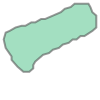

In [12]:
import geopandas as gpd
import os
import pandas as pd

# Folder containing your GeoJSON files
geojson_path = os.path.join(folder_path,"cyan_segmented_polygon_geojson.geojson")
solar_gdf=gpd.read_file(geojson_path)

solar_gdf.geometry.iloc[0]

In [13]:
solar_gdf["centroid"]= solar_gdf.geometry.centroid

C:\Users\Sonika Parashar\AppData\Local\Temp\ipykernel_21476\3858611495.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  solar_gdf["centroid"]= solar_gdf.geometry.centroid


In [14]:
solar_gdf

,color,geometry,centroid
0,red,"POLYGON ((76.79813 30.75015, 76.79812 30.75015...",POINT (76.79811 30.75013)
1,red,"POLYGON ((76.79809 30.75019, 76.79809 30.75019...",POINT (76.79809 30.75017)
2,red,"POLYGON ((76.79813 30.75022, 76.79813 30.75022...",POINT (76.79812 30.75021)
3,red,"POLYGON ((76.79855 30.75595, 76.79855 30.75595...",POINT (76.79855 30.75594)
4,red,"POLYGON ((76.79858 30.756, 76.79858 30.75599, ...",POINT (76.7986 30.75599)
...,...,...,...
75,red,"POLYGON ((76.80193 30.75284, 76.80193 30.7528,...",POINT (76.80194 30.75281)
76,red,"POLYGON ((76.80279 30.75003, 76.80279 30.75003...",POINT (76.80276 30.75001)
77,red,"POLYGON ((76.80257 30.75032, 76.80257 30.75032...",POINT (76.80252 30.75028)
78,red,"POLYGON ((76.80256 30.75236, 76.80256 30.75236...",POINT (76.80252 30.75235)


In [15]:
solar_data=os.path.join(folder_path,'solar_panel_centroid.csv')
# solar_gdf.to_csv("D:\solar_panel_detection\data\solar_panel_centroid.csv")
solar_gdf.to_csv(solar_data)

In [ ]:
house_polygon_path = os.path.join(webscrapping_path, 'plots_in_chandigarh_Sec_1.csv')           ## chandigarh house data
#house_gdf= gpd.read_file(r"C:\Users\Sonika Parashar\Documents\Chandigarh_solar_panels\test_data\webscrap\plots_in_chandigarh_Sec_1.csv", ignore_geometry = True)
house_gdf= gpd.read_file(house_polygon_path, ignore_geometry = True)
house_gdf

,latitude,longitude,area_in_meters,confidence,geometry,full_plus_code
0,30.75180438,76.79925297,182.7184,0.8506,"POLYGON ((76.7993431437145 30.7517928652495, 7...",8J2RQQ2X+PPC2
1,30.75262707,76.79844685,32.3303,0.8217,"POLYGON ((76.7984867073253 30.7526154511203, 7...",8J2RQQ3X+3943
2,30.75260553,76.80018948,83.9537,0.7617,"POLYGON ((76.800265077786 30.7526156555589, 76...",8J2RQR32+23W6
3,30.7503868,76.80006102,22.6957,0.6814,"POLYGON ((76.8000633882534 30.750419872837, 76...",8J2RQR22+523H
4,30.75307528,76.79904087,176.5565,0.6962,"POLYGON ((76.7989673573573 30.7529948864755, 7...",8J2RQQ3X+6JM3
...,...,...,...,...,...,...
174,30.75247811,76.80000205,152.3719,0.7952,"POLYGON ((76.8001000477977 30.7524854767137, 7...",8J2RQR22+X2R2
175,30.75338063,76.80029787,20.8076,0.6792,"POLYGON ((76.8003300679107 30.7533720593087, 7...",8J2RQR32+9438
176,30.75226179,76.79898902,91.7641,0.8271,"POLYGON ((76.7989788645013 30.752328363004, 76...",8J2RQQ2X+WH5G
177,30.75226457,76.80253521,641.7516,0.8003,"POLYGON ((76.802463922147 30.7522670419056, 76...",8J2RQR23+W23C


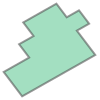

In [17]:
from shapely.wkt import loads  # Import the loads function to convert WKT to geometry
house_gdf['geometry']= house_gdf.geometry.apply(loads)
house_gdf = gpd.GeoDataFrame(house_gdf,geometry = 'geometry')
house_gdf.geometry.iloc[0]

In [18]:
house_gdf

,latitude,longitude,area_in_meters,confidence,geometry,full_plus_code
0,30.75180438,76.79925297,182.7184,0.8506,"POLYGON ((76.79934 30.75179, 76.79931 30.75184...",8J2RQQ2X+PPC2
1,30.75262707,76.79844685,32.3303,0.8217,"POLYGON ((76.79849 30.75262, 76.79846 30.75266...",8J2RQQ3X+3943
2,30.75260553,76.80018948,83.9537,0.7617,"POLYGON ((76.80027 30.75262, 76.80023 30.75266...",8J2RQR32+23W6
3,30.7503868,76.80006102,22.6957,0.6814,"POLYGON ((76.80006 30.75042, 76.80003 30.75041...",8J2RQR22+523H
4,30.75307528,76.79904087,176.5565,0.6962,"POLYGON ((76.79897 30.75299, 76.79916 30.75309...",8J2RQQ3X+6JM3
...,...,...,...,...,...,...
174,30.75247811,76.80000205,152.3719,0.7952,"POLYGON ((76.8001 30.75249, 76.80005 30.75255,...",8J2RQR22+X2R2
175,30.75338063,76.80029787,20.8076,0.6792,"POLYGON ((76.80033 30.75337, 76.80031 30.75341...",8J2RQR32+9438
176,30.75226179,76.79898902,91.7641,0.8271,"POLYGON ((76.79898 30.75233, 76.79892 30.75229...",8J2RQQ2X+WH5G
177,30.75226457,76.80253521,641.7516,0.8003,"POLYGON ((76.80246 30.75227, 76.80251 30.75223...",8J2RQR23+W23C


In [ ]:
# type(house_gdf)

geopandas.geodataframe.GeoDataFrame

In [21]:
solar_gdf

,color,geometry,centroid
0,red,"POLYGON ((76.79792 30.75014, 76.79791 30.75014...",POINT (76.79789 30.75012)
1,red,"POLYGON ((76.79788 30.75018, 76.79787 30.75018...",POINT (76.79787 30.75016)
2,red,"POLYGON ((76.79792 30.75021, 76.79791 30.75021...",POINT (76.79791 30.7502)
3,red,"POLYGON ((76.79834 30.75594, 76.79833 30.75594...",POINT (76.79833 30.75593)
4,red,"POLYGON ((76.79836 30.75599, 76.79836 30.75598...",POINT (76.79838 30.75598)
...,...,...,...
75,red,"POLYGON ((76.80171 30.75283, 76.80171 30.75279...",POINT (76.80172 30.7528)
76,red,"POLYGON ((76.80257 30.75002, 76.80257 30.75002...",POINT (76.80254 30.75)
77,red,"POLYGON ((76.80235 30.75031, 76.80235 30.75031...",POINT (76.8023 30.75027)
78,red,"POLYGON ((76.80235 30.75235, 76.80234 30.75235...",POINT (76.8023 30.75234)


In [19]:
import geopandas as gpd
 
# Ensure both GeoDataFrames have the same CRS

# solar_gdf = solar_gdf.to_crs(house_gdf.crs)
 
# Use only the centroid geometry column for solar_gdf

solar_centroids = solar_gdf[['centroid']].copy()

solar_centroids = solar_centroids.set_geometry('centroid')
 
# Perform spatial join: keep only points that are within polygons

joined = gpd.sjoin(solar_centroids, house_gdf, how='inner', predicate='within')
 
# Count how many points fall into each polygon (house)

point_counts = joined.groupby('index_right').size()
 
# Assign the counts back to house_gdf

house_gdf['solar_point_count'] = house_gdf.index.map(point_counts).fillna(0).astype(int)
 

C:\Users\Sonika Parashar\AppData\Local\Temp\ipykernel_21476\274163193.py:15: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: None

  joined = gpd.sjoin(solar_centroids, house_gdf, how='inner', predicate='within')


In [ ]:
house_data=os.path.join(folder_path,'house_solar_count.csv')
# solar_gdf.to_csv("D:\solar_panel_detection\data\solar_panel_centroid.csv")
house_gdf.to_csv(house_data)

,latitude,longitude,area_in_meters,confidence,geometry,full_plus_code,solar_point_count
0,30.75180438,76.79925297,182.7184,0.8506,"POLYGON ((76.79934 30.75179, 76.79931 30.75184...",8J2RQQ2X+PPC2,0
1,30.75262707,76.79844685,32.3303,0.8217,"POLYGON ((76.79849 30.75262, 76.79846 30.75266...",8J2RQQ3X+3943,0
2,30.75260553,76.80018948,83.9537,0.7617,"POLYGON ((76.80027 30.75262, 76.80023 30.75266...",8J2RQR32+23W6,0
3,30.7503868,76.80006102,22.6957,0.6814,"POLYGON ((76.80006 30.75042, 76.80003 30.75041...",8J2RQR22+523H,0
4,30.75307528,76.79904087,176.5565,0.6962,"POLYGON ((76.79897 30.75299, 76.79916 30.75309...",8J2RQQ3X+6JM3,0
...,...,...,...,...,...,...,...
174,30.75247811,76.80000205,152.3719,0.7952,"POLYGON ((76.8001 30.75249, 76.80005 30.75255,...",8J2RQR22+X2R2,1
175,30.75338063,76.80029787,20.8076,0.6792,"POLYGON ((76.80033 30.75337, 76.80031 30.75341...",8J2RQR32+9438,0
176,30.75226179,76.79898902,91.7641,0.8271,"POLYGON ((76.79898 30.75233, 76.79892 30.75229...",8J2RQQ2X+WH5G,0
177,30.75226457,76.80253521,641.7516,0.8003,"POLYGON ((76.80246 30.75227, 76.80251 30.75223...",8J2RQR23+W23C,0
